In [63]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter 
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import CSVLoader
from langchain_core.tools import Tool
from langgraph.prebuilt import ToolNode
from typing import Annotated,Sequence, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
from typing import Literal
from pydantic import BaseModel, Field
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import tools_condition
from langchain_core.messages import HumanMessage
from pprint import pprint


In [2]:
file_path=r"C:\Users\hardi\OneDrive\Desktop\begproject_pdfchatbot\Delhi metro.csv"
csv_loader = CSVLoader(file_path)
routes = csv_loader.load()

In [3]:
urls=[
    "https://livemad-ness.blogspot.com/2016/10/a-journey-via-delhi-metro.html",
    "https://www.intrepidtravel.com/adventures/guide-delhi-metro-india/",
    "https://www.reiasindia.com/blog/delhi-metro-revolutionary-change-in-urban-transport",
]
docs=[WebBaseLoader(url).load() for url in urls]
docs_list=[item for sublist in docs for item in sublist]

In [4]:
docs_list

[Document(metadata={'source': 'https://livemad-ness.blogspot.com/2016/10/a-journey-via-delhi-metro.html', 'title': 'A journey via Delhi metro - NoMads', 'description': '', 'language': 'No language found.'}, page_content="\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nA journey via Delhi metro - NoMads\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nNoMads\n\n\n\n\nEnergy comes from knowing the truth that life is short and we need to learn to live and live to learn.\n\n\n\n\n\n\n\n Menu\n\nHome\n\nTravel\n\n\nKarnataka\n\nNorth Karnataka\nMysore\nKodagu\nMangalore-Udupi\nWestern Ghats-Karwar coast\n\n\n\nSouth\n\nKerala\nTamilnadu\nTelangana\nPuducherry\n\n\n\nWest\n\nMaharashtra\nGujarat\nGoa\n\n\n\nNorth\n\nDelhi\nHimachal Pradesh\nUttarakhand\nUttar Pradesh\n\n\n\n\nTeam\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\narchitectures\n\nDelhi\n\nMetro\n\nA journey via Delhi metro\n\n\n\n\n\n\n\n\n\nA journey via Delhi metro\n\n\n\n\n\n\n\nSanthosh Kumar B

In [5]:
embeddings = HuggingFaceEmbeddings(model="sentence-transformers/all-MiniLM-L6-v2")

In [6]:
text_splitter=RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=100,chunk_overlap=25)
blogs_split=text_splitter.split_documents(docs_list)
routes_split=text_splitter.split_documents(routes)
all_data=blogs_split+routes_split
vectorstore=Chroma.from_documents(
    documents=all_data,
    collection_name="delhi-metro",
    embedding=embeddings  
)

In [56]:
retriever=vectorstore.as_retriever()
llm=ChatGroq(model="openai/gpt-oss-120b")
retriever_tool = Tool(
    name="retriever",
    description="Search and return relevant information about Delhi Metro from the routs or blog posts",
    func=retriever.invoke)
tools=[retriever_tool]
retriever_node=ToolNode(tools)
llm_with_tool=llm.bind_tools(tools)

In [57]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

def LLM_Decision_Maker(state:AgentState):
    print("----CALL LLM_DECISION_MAKE----")
    message=state["messages"]
    last_message=message[-1]
    question=last_message.content
    response=llm_with_tool.invoke(message)
    return {"messages":[response]}

In [51]:
class grade(BaseModel):
    binary_score:str=Field(description="Relvance score 'yes' or 'no'")

def grade_documents(state:AgentState)->Literal["Output Generator", "Query Rewriter"]:
    print("----CALLING GRADE FOR CHECKING RELEVANCY----")
    llm_with_structure_op=llm.with_structured_output(grade)
    prompt=PromptTemplate(
        template="""You are a grader deciding if a information or metro route is relevant to a user’s question.
                    Here is the information: {context}
                    Here is the user’s question: {question}
                    If the document talks about or contains information related to the user’s question, mark it as relevant. 
                    Give a 'yes' or 'no' answer to show if the document is relevant to the question.""",
                    input_variables=["context", "question"]
                    )
     
    chain=prompt|llm_with_structure_op
    message=state['messages']
    last_message = message[-1]
    question = message[0].content
    docs = last_message.content
    scored_result=chain.invoke({"question": question, "context": docs})
    score=scored_result.binary_score
    if score=="yes":
        print("----DECISION: DOCS ARE RELEVANT----")
        return "generator"
    else:
        print("----DECISION: DOCS ARE NOT RELEVANT----")
        return "rewriter"

In [52]:
def generate(state:AgentState):
    print("----RAG OUTPUT GENERATE----")
    message=state["messages"]
    question=message[0].content
    last_message = message[-1]
    docs = last_message.content
    prompt=PromptTemplate(
        template="""You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know.
                    Use three sentences maximum and keep the answer concise.
                    Question: {question} 
                    Context: {context} 
                    Answer:""",
        input_variables=["question","content"]
    )
    rag_chain=prompt | llm
    response=rag_chain.invoke({"context": docs, "question": question})
    print(f"this is my response:{response}")
    return {"messages": [response]}

In [53]:
def rewrite(state:AgentState):
    print("----TRANSFORM QUERY----")
    message=state["messages"]
    question=message[0].content
    input= [HumanMessage(content=f"""Look at the input and try to reason about the underlying semantic intent or meaning. 
                    Here is the initial question: {question} 
                    Formulate an improved question: """)
       ]
    response=llm.invoke(input)  
    return {"messages": [response]}

In [54]:
workflow=StateGraph(AgentState)
workflow.add_node("LLM Decision Maker",LLM_Decision_Maker)
workflow.add_node("Vector Retriever",retriever_node)
workflow.add_node("Output Generator",generate)
workflow.add_node("Query Rewriter",rewrite)
workflow.add_edge(START,"LLM Decision Maker")
workflow.add_conditional_edges("LLM Decision Maker",
                               tools_condition,
                               {"tools":"Vector Retriever",
                                END:END
                                })
workflow.add_conditional_edges("Vector Retriever",
                               grade_documents,
                               {"generator":"Output Generator",
                                "rewriter":"Query Rewriter"
                                })
workflow.add_edge("Output Generator",END)
workflow.add_edge("Query Rewriter","LLM Decision Maker")
app=workflow.compile()

In [68]:
response=app.invoke({"messages":["Tell me the route to akshardham"]})

----CALL LLM_DECISION_MAKE----
----CALLING GRADE FOR CHECKING RELEVANCY----
----DECISION: DOCS ARE RELEVANT----
----RAG OUTPUT GENERATE----
this is my response:content='Akshardham is on the Delhi Metro’s Blue\u202fLine (Station\u202fID\u202f35). Board a Blue\u202fLine train heading toward Vaishali/Noida\u202fCity Centre and alight at the Akshardham stop. The station is located at latitude\u202f28.61806, longitude\u202f77.27869, about\u202f36.5\u202fkm from the line’s first station.' additional_kwargs={'reasoning_content': 'We need to answer: "Tell me the route to akshardham". Use context. The context includes a CSV entry: Station ID 35, Station Names: Akshardham, Metro Line: Blue line. So route? Probably need to mention that Akshardham is on Blue line, located at 36.5 km from first station. Provide route: take Blue line. Could answer: Take Delhi Metro Blue Line to Akshardham station. That\'s concise. Use three sentences max.'} response_metadata={'token_usage': {'completion_tokens': 194

In [69]:
pprint(response)

{'messages': [HumanMessage(content='Tell me the route to akshardham', additional_kwargs={}, response_metadata={}, id='12141b0a-9488-400f-abc1-f241ce55fedd'),
              AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants route to Akshardham. Likely Delhi Metro route. We need to retrieve info. Use retriever function with query "Akshardham Delhi Metro route".', 'tool_calls': [{'id': 'fc_bcedab89-cba1-4477-a18e-51857c0ddd30', 'function': {'arguments': '{"__arg1":"Akshardham Delhi Metro route"}', 'name': 'retriever'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 145, 'total_tokens': 217, 'completion_time': 0.15261257, 'prompt_time': 0.005547855, 'queue_time': 0.047273915, 'total_time': 0.158160425}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_ff6aa7708c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--c690d8f2-1dc5-436b-8a1

In [77]:
messages = response["messages"]
final_answer = [m.content for m in messages if getattr(m, "content", None)]
print(final_answer[-1])


Akshardham is on the Delhi Metro’s Blue Line (Station ID 35). Board a Blue Line train heading toward Vaishali/Noida City Centre and alight at the Akshardham stop. The station is located at latitude 28.61806, longitude 77.27869, about 36.5 km from the line’s first station.


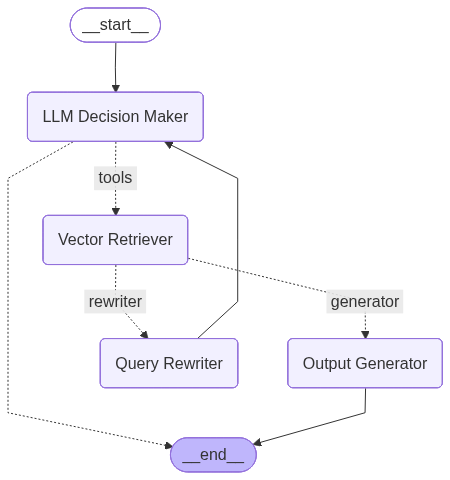

In [31]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod
display(Image(app.get_graph(xray=True).draw_mermaid_png()))